In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
# Configuración
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# Rutas y Mapeo
DATA_PATH = '../../data/processed/dataset_refrigeracion_processed.csv'
MODEL_PATH = '../../models/artifacts/rf_refrigeracion_tuned.pkl'


INPUT_PATH_NOT_SCALED = '../../data/processed/dataset_refrigeracion_processed_not_scaled.csv'

target_mapping = {
    "NORMAL": 0, "COND_FOUL_MILD": 1, "COND_FOUL_SEVERE": 2,
    "EVAP_FAN_DEG": 3, "EVAP_FAN_FAIL": 4, "UNDERCHARGE_MILD": 5,
    "UNDERCHARGE_SEVERE": 6, "OVERCHARGE": 7, "SENSOR_DRIFT_PLUS": 8,
    "SENSOR_DRIFT_MINUS": 9, "COMP_INEFFICIENCY": 10, "NON_CONDENSABLES": 11,
    "UNDERCHARGE_AND_COND_FOUL": 12
}
inv_map = {v: k for k, v in target_mapping.items()}

In [165]:
df = pd.read_csv(DATA_PATH)
df_not_scaled = pd.read_csv(INPUT_PATH_NOT_SCALED)

rf_classifier = joblib.load(MODEL_PATH)

# Separar test (mismo split que en tuning)
run_labels = df.groupby('run_id')['fault_id'].first()
_, test_runs = train_test_split(run_labels.index, test_size=0.2, random_state=42, stratify=run_labels)

test_df_not_scaled = df_not_scaled[df_not_scaled['run_id'].isin(test_runs)].copy()

test_df = df[df['run_id'].isin(test_runs)].copy()
X_test = test_df.drop(columns=['fault_id', 'fault', 'run_id', 'time_min'])
y_test = test_df['fault_id']

print(f"Dataset de evaluación listo: {X_test.shape[0]} muestras.")

Dataset de evaluación listo: 372060 muestras.


In [166]:
# 1. Replicamos el split para identificar qué runs son de entrenamiento
run_labels_all = df_not_scaled.groupby('run_id')['fault_id'].first()
train_runs_idx, _ = train_test_split(
    run_labels_all.index, 
    test_size=0.2, 
    random_state=42, 
    stratify=run_labels_all
)

# 2. Creamos el dataframe de entrenamiento (no escalado) para extraer la física
train_df_phys = df_not_scaled[df_not_scaled['run_id'].isin(train_runs_idx)].copy()

def quantile_threshold(df, feature, label_id, q):
    # Extraemos el cuantil solo de las filas que pertenecen a esa falla en el set de TRAIN
    subset = df[df['fault_id'] == label_id][feature]
    if len(subset) == 0:
        return 0
    return subset.quantile(q)

ids = {name: target_mapping[name] for name in target_mapping}

# 3. Diccionario de umbrales basado EXCLUSIVAMENTE en datos de entrenamiento
THRESHOLDS = {
    "noncond": {
        "P_dis_error_early": {
            "low": quantile_threshold(train_df_phys, "early_P_dis_error", ids["NON_CONDENSABLES"], 0.1)
        },
        "P_dis_mean": {
            "low": quantile_threshold(train_df_phys, "mean_P_dis_bar", ids["NON_CONDENSABLES"], 0.1)
        }
    },
    "cond_foul": {
        "T_cond_approach": {
            "high": quantile_threshold(train_df_phys, "T_cond_approach", ids["COND_FOUL_SEVERE"], 0.9)
        }
    }
}

# Liberamos memoria eliminando el df de entrenamiento una vez calculados los umbrales
del train_df_phys

# --- VERIFICACIÓN ---
print("Umbrales calculados correctamente desde el Set de Entrenamiento:")
print(f"NC Early Error Low (Train): {THRESHOLDS['noncond']['P_dis_error_early']['low']:.4f}")
print(f"CF Approach High (Train):   {THRESHOLDS['cond_foul']['T_cond_approach']['high']:.4f}")

Umbrales calculados correctamente desde el Set de Entrenamiento:
NC Early Error Low (Train): -0.2649
CF Approach High (Train):   10.5713


In [167]:
def apply_neurosymbolic_logic(X_phys_df, model, X_scaled, T, mapping):
    y_pred_original = model.predict(X_scaled)
    y_pred_final = y_pred_original.copy()
    ids = {name: mapping[name] for name in mapping}
    
        # --- REGLAS FÍSICAS (Correcciones puntuales) ---
    # Regla 1: Sensor Drift
    y_pred_final[X_phys_df['T_cab_meas_diff'] > 2.0]  = ids["SENSOR_DRIFT_MINUS"]
    y_pred_final[X_phys_df['T_cab_meas_diff'] < -2.0] = ids["SENSOR_DRIFT_PLUS"]

    # Regla 2: Undercharge
    uc_p_gate = X_phys_df['P_suc_bar'].quantile(0.1)
    y_pred_final[(X_phys_df['P_suc_bar'] < uc_p_gate) & (X_phys_df['SH_K'] > 15)] = ids["UNDERCHARGE_SEVERE"]

    # Regla 3: Inefficiency
    y_pred_final[(X_phys_df['Eff_vol'] < 0.6) & (y_pred_original == ids["NORMAL"])] = ids["COMP_INEFFICIENCY"]

    # --- REGLA 4: EL SWAP SELECTIVO (Basado en física) ---
    nc_phys = (X_phys_df["early_P_dis_error"] > T["noncond"]["P_dis_error_early"]["low"]) & \
              (X_phys_df["T_cond_approach"] < T["cond_foul"]["T_cond_approach"]["high"] * 0.88)
    
    cf_phys = (X_phys_df["T_cond_approach"] > T["cond_foul"]["T_cond_approach"]["high"]) & \
              (X_phys_df["early_P_dis_error"] < T["noncond"]["P_dis_error_early"]["low"] * 1.2)

    in_scope = (y_pred_original == ids["NON_CONDENSABLES"]) | (y_pred_original == ids["COND_FOUL_SEVERE"])
    
    # Aplicamos primero el swap basado en evidencia física
    y_pred_final[in_scope & (y_pred_original == ids["NON_CONDENSABLES"]) & cf_phys] = ids["COND_FOUL_SEVERE"]
    y_pred_final[in_scope & (y_pred_original == ids["COND_FOUL_SEVERE"]) & nc_phys] = ids["NON_CONDENSABLES"]

  
    
    temp_nc_mask = (y_pred_final == ids["NON_CONDENSABLES"])
    temp_cf_mask = (y_pred_final == ids["COND_FOUL_SEVERE"])
    
    y_pred_final[temp_nc_mask] = ids["COND_FOUL_SEVERE"]
    y_pred_final[temp_cf_mask] = ids["NON_CONDENSABLES"]
    
    return y_pred_final 

# Ejecutar inferencia
y_pred_pure = rf_classifier.predict(X_test)
y_pred_ns = apply_neurosymbolic_logic(test_df_not_scaled, rf_classifier, X_test, THRESHOLDS, target_mapping)

In [168]:
def apply_run_voting(df, predictions):
    df_v = df.copy()
    df_v['preds'] = predictions
    # El modelo decide la falla predominante en todo el ciclo de funcionamiento
    return df_v.groupby('run_id')['preds'].transform(lambda x: x.value_counts().idxmax()).values

y_pred_final = apply_run_voting(test_df_not_scaled, y_pred_ns)

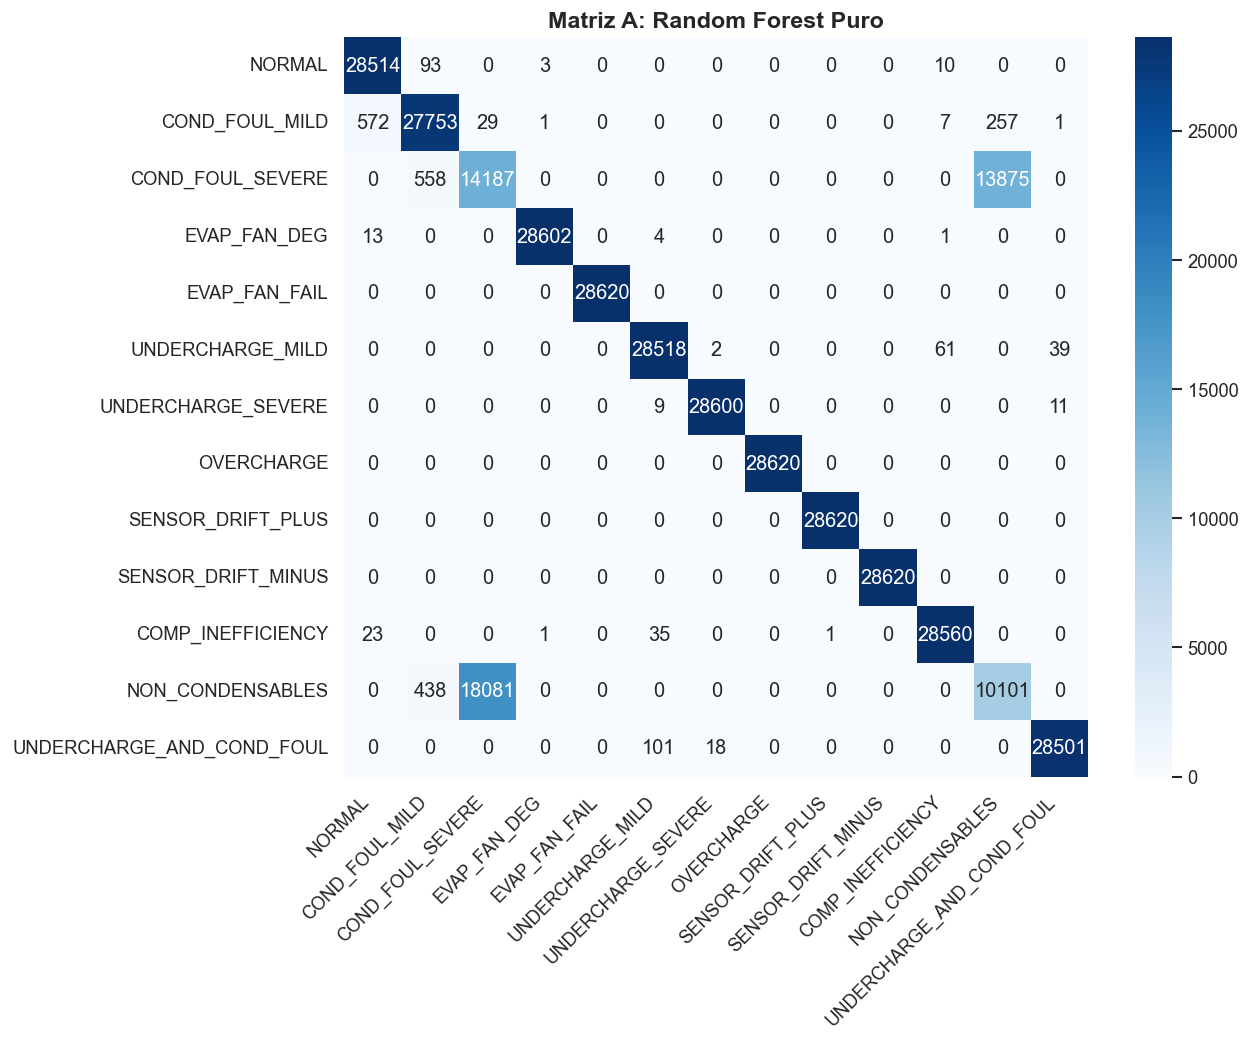

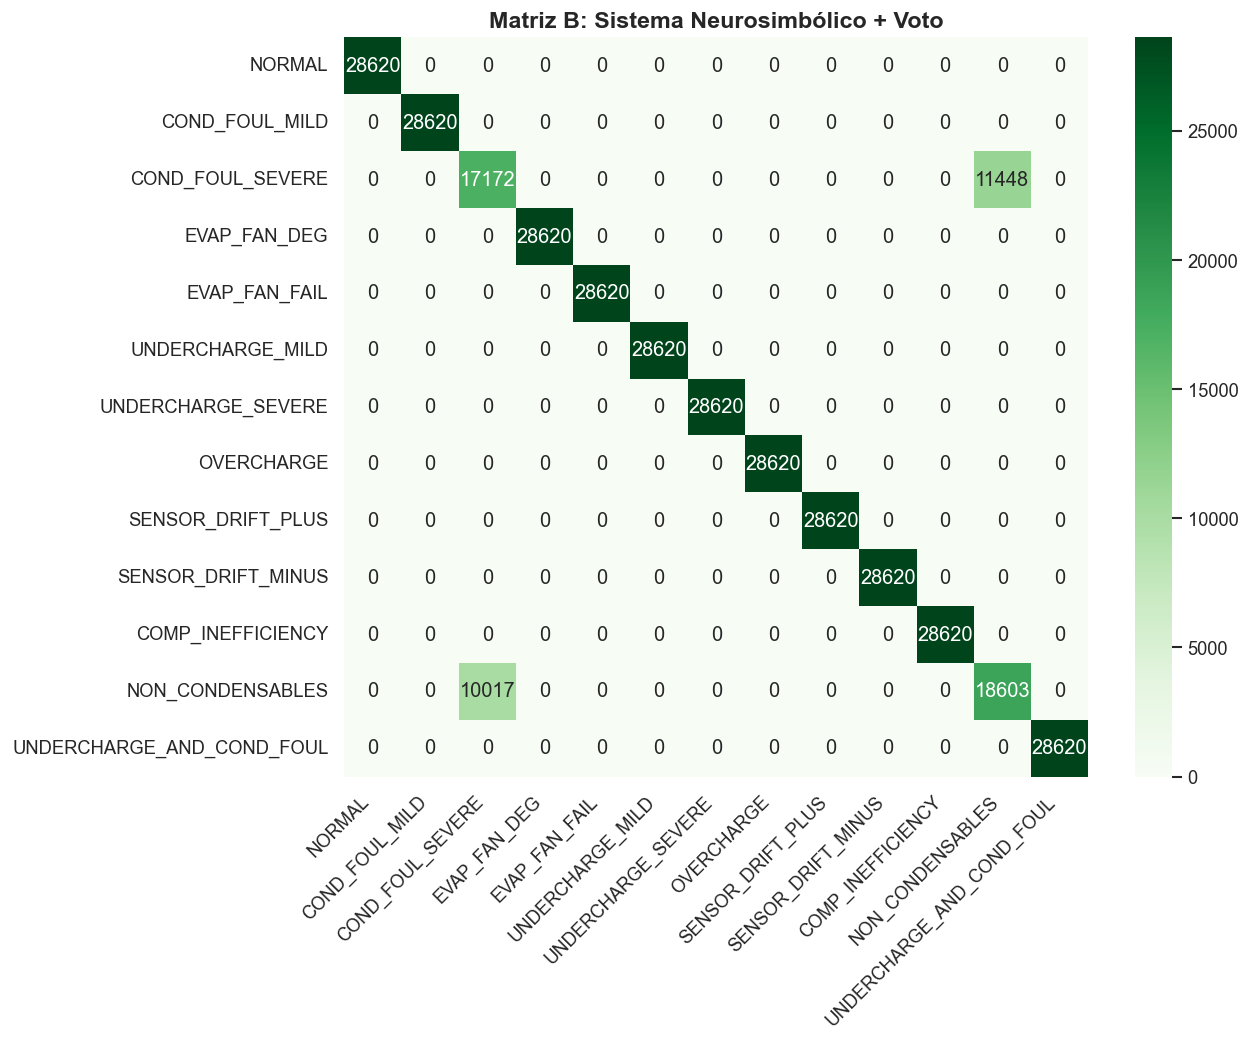

In [ ]:
def plot_results(y_true, y_pred, title, color):
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    
    labels = [inv_map[i] for i in sorted(target_mapping.values())]
    plt.xticks(np.arange(len(labels)) + 0.5, labels, rotation=45, ha='right')
    plt.yticks(np.arange(len(labels)) + 0.5, labels, rotation=0)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()

# Comparativa entre modelo puro y sistema completo
plot_results(y_test, y_pred_pure, "Matriz A: Random Forest Puro", "Blues")
plot_results(y_test, y_pred_final, "Matriz B: Sistema Neurosimbólico + Voto", "Greens")

In [170]:
print("--- RENDIMIENTO FINAL DEL SISTEMA DE REFRIGERACIÓN ---")
print(classification_report(y_test, y_pred_final, target_names=list(target_mapping.keys())))

--- RENDIMIENTO FINAL DEL SISTEMA DE REFRIGERACIÓN ---
                           precision    recall  f1-score   support

                   NORMAL       1.00      1.00      1.00     28620
           COND_FOUL_MILD       1.00      1.00      1.00     28620
         COND_FOUL_SEVERE       0.63      0.60      0.62     28620
             EVAP_FAN_DEG       1.00      1.00      1.00     28620
            EVAP_FAN_FAIL       1.00      1.00      1.00     28620
         UNDERCHARGE_MILD       1.00      1.00      1.00     28620
       UNDERCHARGE_SEVERE       1.00      1.00      1.00     28620
               OVERCHARGE       1.00      1.00      1.00     28620
        SENSOR_DRIFT_PLUS       1.00      1.00      1.00     28620
       SENSOR_DRIFT_MINUS       1.00      1.00      1.00     28620
        COMP_INEFFICIENCY       1.00      1.00      1.00     28620
         NON_CONDENSABLES       0.62      0.65      0.63     28620
UNDERCHARGE_AND_COND_FOUL       1.00      1.00      1.00     28620

     